In [1]:
!pip install xgboost -q

In [3]:
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

from xgboost import XGBRegressor

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [4]:
os.makedirs("outputs", exist_ok=True)
os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)

In [5]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/alistairking/public-company-esg-ratings-dataset/data.csv
/kaggle/input/datasets/jaidityachopra/esg-sustainability-reports-of-s-and-p-500-companies/preprocessed_content.csv


In [7]:
esg = pd.read_csv(
    "/kaggle/input/datasets/alistairking/public-company-esg-ratings-dataset/data.csv"
)

print(esg.shape)
esg.head()

(722, 21)


,ticker,name,currency,exchange,industry,logo,weburl,environment_grade,environment_level,social_grade,...,governance_grade,governance_level,environment_score,social_score,governance_score,total_score,last_processing_date,total_grade,total_level,cik
0,dis,Walt Disney Co,USD,"NEW YORK STOCK EXCHANGE, INC.",Media,https://static.finnhub.io/logo/ef50b4a2b263c84...,https://thewaltdisneycompany.com/,A,High,BB,...,BB,Medium,510,316,321,1147,19-04-2022,BBB,High,1744489
1,gm,General Motors Co,USD,"NEW YORK STOCK EXCHANGE, INC.",Automobiles,https://static.finnhub.io/logo/9253db78-80c9-1...,https://www.gm.com/,A,High,BB,...,B,Medium,510,303,255,1068,17-04-2022,BBB,High,1467858
2,gww,WW Grainger Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Trading Companies and Distributors,https://static.finnhub.io/logo/f153dcda-80eb-1...,https://www.grainger.com/,B,Medium,BB,...,B,Medium,255,385,240,880,19-04-2022,BB,Medium,277135
3,mhk,Mohawk Industries Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Consumer products,https://static.finnhub.io/logo/26868a62-80ec-1...,https://mohawkind.com/,A,High,B,...,BB,Medium,570,298,303,1171,18-04-2022,BBB,High,851968
4,lyv,Live Nation Entertainment Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Media,https://static.finnhub.io/logo/1cd144d2-80ec-1...,https://www.livenationentertainment.com/,BBB,High,BB,...,B,Medium,492,310,250,1052,18-04-2022,BBB,High,1335258


In [8]:
print(esg.columns.tolist())

['ticker', 'name', 'currency', 'exchange', 'industry', 'logo', 'weburl', 'environment_grade', 'environment_level', 'social_grade', 'social_level', 'governance_grade', 'governance_level', 'environment_score', 'social_score', 'governance_score', 'total_score', 'last_processing_date', 'total_grade', 'total_level', 'cik']


In [9]:
df = esg.copy()

features = [
    "environment_score",
    "social_score",
    "governance_score",
    "industry"
]

target = "total_score"

df = df[features + [target]]

df.head()

,environment_score,social_score,governance_score,industry,total_score
0,510,316,321,Media,1147
1,510,303,255,Automobiles,1068
2,255,385,240,Trading Companies and Distributors,880
3,570,298,303,Consumer products,1171
4,492,310,250,Media,1052


In [10]:
df = df.dropna(subset=[target])

df["industry"] = df["industry"].fillna("Unknown")

for col in [
    "environment_score",
    "social_score",
    "governance_score"
]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [11]:
encoder = LabelEncoder()

df["industry"] = encoder.fit_transform(df["industry"].astype(str))

In [12]:
df = df.dropna()

print(df.shape)

(722, 5)


In [13]:
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(577, 4)
(145, 4)


In [15]:
def evaluate_model(X_train, X_test, y_train, y_test):

    model = XGBRegressor(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        random_state=42
    )

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    rmse = np.sqrt(
        mean_squared_error(y_test, preds)
    )

    mae = mean_absolute_error(
        y_test,
        preds
    )

    r2 = r2_score(
        y_test,
        preds
    )

    return rmse, mae, r2

In [17]:
missing_levels = [0, 10, 20, 30, 40]

results = []

In [18]:
for pct in missing_levels:

    X_train_missing = X_train.copy()
    X_test_missing = X_test.copy()

    if pct > 0:

        for col in X_train_missing.columns:

            train_mask = (
                np.random.rand(len(X_train_missing))
                < pct / 100
            )

            test_mask = (
                np.random.rand(len(X_test_missing))
                < pct / 100
            )

            X_train_missing.loc[
                train_mask,
                col
            ] = np.nan

            X_test_missing.loc[
                test_mask,
                col
            ] = np.nan

    imputer = SimpleImputer(
        strategy="median"
    )

    X_train_imp = pd.DataFrame(
        imputer.fit_transform(X_train_missing),
        columns=X_train_missing.columns
    )

    X_test_imp = pd.DataFrame(
        imputer.transform(X_test_missing),
        columns=X_test_missing.columns
    )

    rmse, mae, r2 = evaluate_model(
        X_train_imp,
        X_test_imp,
        y_train,
        y_test
    )

    results.append(
        [
            pct,
            rmse,
            mae,
            r2
        ]
    )

print("Completed")

Completed


In [19]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Missing_Data_Percent",
        "RMSE",
        "MAE",
        "R2"
    ]
)

results_df

,Missing_Data_Percent,RMSE,MAE,R2
0,0,13.394484,8.682367,0.995954
1,10,54.800011,28.465631,0.932269
2,20,70.842875,39.222004,0.886808
3,30,88.559186,55.035408,0.823115
4,40,127.184091,82.488281,0.635171


In [20]:
results_df.to_csv(
    "outputs/tables/rq1_robustness_results.csv",
    index=False
)

print("CSV saved.")

CSV saved.


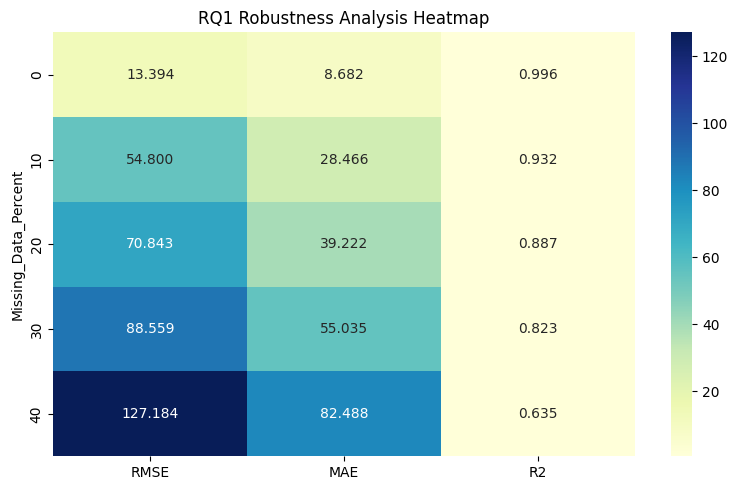

In [21]:
heatmap_data = results_df.set_index(
    "Missing_Data_Percent"
)[["RMSE","MAE","R2"]]

plt.figure(figsize=(8,5))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="YlGnBu",
    fmt=".3f"
)

plt.title(
    "RQ1 Robustness Analysis Heatmap"
)

plt.tight_layout()

plt.savefig(
    "outputs/figures/rq1_robustness_heatmap.pdf",
    bbox_inches="tight"
)

plt.show()

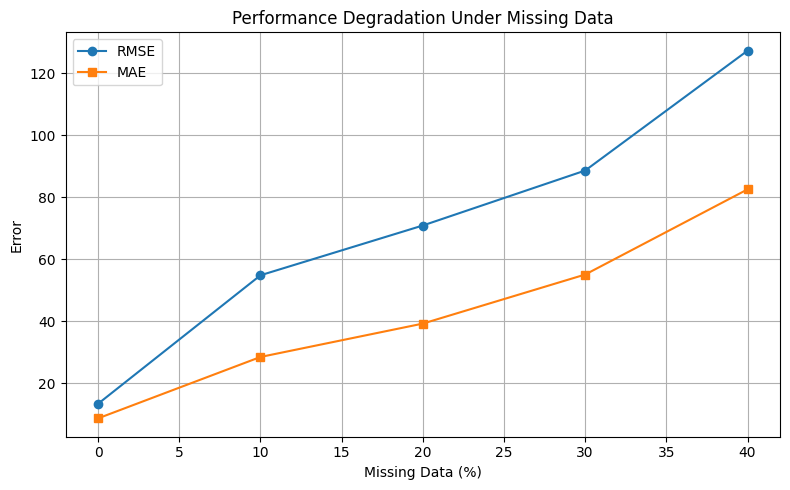

In [22]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df["Missing_Data_Percent"],
    results_df["RMSE"],
    marker="o",
    label="RMSE"
)

plt.plot(
    results_df["Missing_Data_Percent"],
    results_df["MAE"],
    marker="s",
    label="MAE"
)

plt.xlabel(
    "Missing Data (%)"
)

plt.ylabel(
    "Error"
)

plt.title(
    "Performance Degradation Under Missing Data"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "outputs/figures/rq1_performance_degradation.pdf",
    bbox_inches="tight"
)

plt.show()

In [23]:
print("="*50)
print("RQ1 COMPLETE")
print("="*50)

print("\nGenerated Files:\n")

print(
    "outputs/tables/rq1_robustness_results.csv"
)

print(
    "outputs/figures/rq1_robustness_heatmap.pdf"
)

print(
    "outputs/figures/rq1_performance_degradation.pdf"
)

results_df

RQ1 COMPLETE

Generated Files:

outputs/tables/rq1_robustness_results.csv
outputs/figures/rq1_robustness_heatmap.pdf
outputs/figures/rq1_performance_degradation.pdf


,Missing_Data_Percent,RMSE,MAE,R2
0,0,13.394484,8.682367,0.995954
1,10,54.800011,28.465631,0.932269
2,20,70.842875,39.222004,0.886808
3,30,88.559186,55.035408,0.823115
4,40,127.184091,82.488281,0.635171


In [24]:
!pip install xgboost shap -q

In [25]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from xgboost import XGBRegressor

import shap

import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
os.makedirs("outputs", exist_ok=True)
os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)

In [28]:
esg = pd.read_csv(
    "/kaggle/input/datasets/alistairking/public-company-esg-ratings-dataset/data.csv"
)

print(esg.shape)
esg.head()

(722, 21)


,ticker,name,currency,exchange,industry,logo,weburl,environment_grade,environment_level,social_grade,...,governance_grade,governance_level,environment_score,social_score,governance_score,total_score,last_processing_date,total_grade,total_level,cik
0,dis,Walt Disney Co,USD,"NEW YORK STOCK EXCHANGE, INC.",Media,https://static.finnhub.io/logo/ef50b4a2b263c84...,https://thewaltdisneycompany.com/,A,High,BB,...,BB,Medium,510,316,321,1147,19-04-2022,BBB,High,1744489
1,gm,General Motors Co,USD,"NEW YORK STOCK EXCHANGE, INC.",Automobiles,https://static.finnhub.io/logo/9253db78-80c9-1...,https://www.gm.com/,A,High,BB,...,B,Medium,510,303,255,1068,17-04-2022,BBB,High,1467858
2,gww,WW Grainger Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Trading Companies and Distributors,https://static.finnhub.io/logo/f153dcda-80eb-1...,https://www.grainger.com/,B,Medium,BB,...,B,Medium,255,385,240,880,19-04-2022,BB,Medium,277135
3,mhk,Mohawk Industries Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Consumer products,https://static.finnhub.io/logo/26868a62-80ec-1...,https://mohawkind.com/,A,High,B,...,BB,Medium,570,298,303,1171,18-04-2022,BBB,High,851968
4,lyv,Live Nation Entertainment Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Media,https://static.finnhub.io/logo/1cd144d2-80ec-1...,https://www.livenationentertainment.com/,BBB,High,BB,...,B,Medium,492,310,250,1052,18-04-2022,BBB,High,1335258


In [29]:
print(esg.columns.tolist())

['ticker', 'name', 'currency', 'exchange', 'industry', 'logo', 'weburl', 'environment_grade', 'environment_level', 'social_grade', 'social_level', 'governance_grade', 'governance_level', 'environment_score', 'social_score', 'governance_score', 'total_score', 'last_processing_date', 'total_grade', 'total_level', 'cik']


In [30]:
df = esg.copy()

target = "total_score"

features = [
    "environment_score",
    "social_score",
    "governance_score",
    "industry"
]

df = df[features + [target]]

df.head()

,environment_score,social_score,governance_score,industry,total_score
0,510,316,321,Media,1147
1,510,303,255,Automobiles,1068
2,255,385,240,Trading Companies and Distributors,880
3,570,298,303,Consumer products,1171
4,492,310,250,Media,1052


In [32]:
df["industry"] = df["industry"].fillna("Unknown")

for col in [
    "environment_score",
    "social_score",
    "governance_score"
]:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

df = df.dropna()

In [35]:
encoder = LabelEncoder()

df["industry"] = encoder.fit_transform(
    df["industry"].astype(str)
)

In [38]:
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [39]:
model = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [40]:
preds = model.predict(X_test)

rmse = np.sqrt(
    mean_squared_error(y_test, preds)
)

mae = mean_absolute_error(
    y_test,
    preds
)

r2 = r2_score(
    y_test,
    preds
)

print("RMSE:", round(rmse,3))
print("MAE :", round(mae,3))
print("R²  :", round(r2,3))

RMSE: 13.148
MAE : 8.272
R²  : 0.996


In [41]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

print(shap_values.shape)

(145, 4)


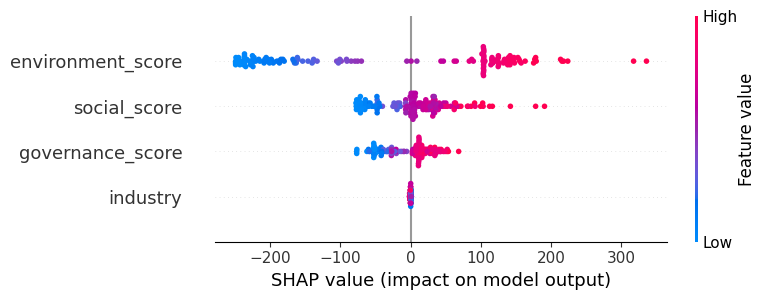

In [42]:
plt.figure()

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.tight_layout()

plt.savefig(
    "outputs/figures/rq2_shap_summary_plot.pdf",
    bbox_inches="tight"
)

plt.show()

In [43]:
importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean_SHAP_Value":
    np.abs(shap_values).mean(axis=0)
})

importance_df = (
    importance_df
    .sort_values(
        by="Mean_SHAP_Value",
        ascending=False
    )
)

importance_df

,Feature,Mean_SHAP_Value
0,environment_score,157.260925
1,social_score,41.780430
2,governance_score,29.594049
3,industry,0.374550


In [44]:
importance_df["Rank"] = range(
    1,
    len(importance_df)+1
)

importance_df = importance_df[
    [
        "Rank",
        "Feature",
        "Mean_SHAP_Value"
    ]
]

importance_df

,Rank,Feature,Mean_SHAP_Value
0,1,environment_score,157.260925
1,2,social_score,41.780430
2,3,governance_score,29.594049
3,4,industry,0.374550


In [45]:
importance_df.to_csv(
    "outputs/tables/rq2_feature_importance.csv",
    index=False
)

print("Table saved.")

Table saved.


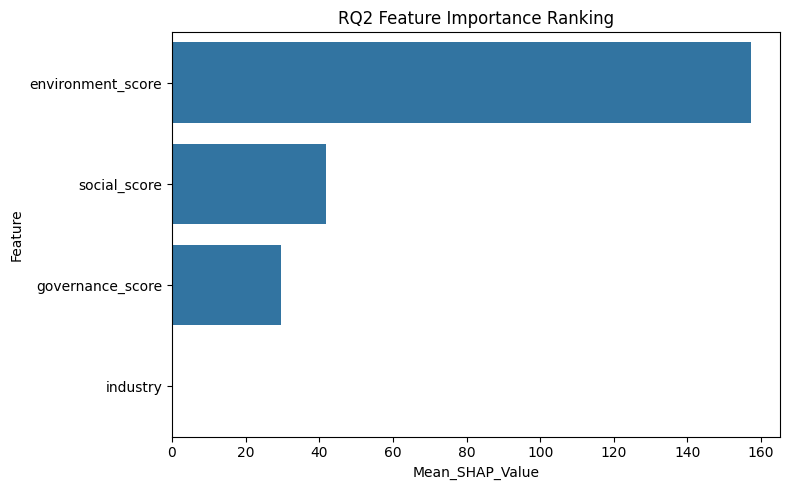

In [46]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance_df,
    x="Mean_SHAP_Value",
    y="Feature"
)

plt.title(
    "RQ2 Feature Importance Ranking"
)

plt.tight_layout()

plt.savefig(
    "outputs/figures/rq2_feature_importance_barplot.pdf",
    bbox_inches="tight"
)

plt.show()

In [47]:
results_table = importance_df.copy()

results_table.columns = [
    "Rank",
    "Feature",
    "Mean_SHAP_Value"
]

results_table

,Rank,Feature,Mean_SHAP_Value
0,1,environment_score,157.260925
1,2,social_score,41.780430
2,3,governance_score,29.594049
3,4,industry,0.374550


In [50]:
results_table.to_csv(
    "outputs/tables/rq2_top_contributing_features.csv",
    index=False
)

In [51]:
top_feature = results_table.iloc[0]["Feature"]

print(
    f"Most influential ESG factor: {top_feature}"
)

Most influential ESG factor: environment_score


In [52]:
print("="*50)
print("RQ2 COMPLETE")
print("="*50)

print("\nGenerated Files:\n")

print(
    "outputs/figures/rq2_shap_summary_plot.pdf"
)

print(
    "outputs/figures/rq2_feature_importance_barplot.pdf"
)

print(
    "outputs/tables/rq2_feature_importance.csv"
)

print(
    "outputs/tables/rq2_top_contributing_features.csv"
)

results_table.head()

RQ2 COMPLETE

Generated Files:

outputs/figures/rq2_shap_summary_plot.pdf
outputs/figures/rq2_feature_importance_barplot.pdf
outputs/tables/rq2_feature_importance.csv
outputs/tables/rq2_top_contributing_features.csv


,Rank,Feature,Mean_SHAP_Value
0,1,environment_score,157.260925
1,2,social_score,41.780430
2,3,governance_score,29.594049
3,4,industry,0.374550


In [53]:
!pip install xgboost -q

In [58]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from xgboost import XGBRegressor

import matplotlib.pyplot as plt
import seaborn as sns

In [60]:
os.makedirs("outputs", exist_ok=True)
os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)

In [62]:
esg = pd.read_csv(
    "/kaggle/input/datasets/alistairking/public-company-esg-ratings-dataset/data.csv"
)

print(esg.shape)

(722, 21)


In [67]:
df = esg.copy()

target = "total_score"

features = [
    "environment_score",
    "social_score",
    "governance_score",
    "industry"
]

df = df[features + [target]]

In [69]:
df["industry"] = df["industry"].fillna("Unknown")

for col in [
    "environment_score",
    "social_score",
    "governance_score"
]:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

df = df.dropna()

In [70]:
df["industry_original"] = df["industry"]

In [71]:
encoder = LabelEncoder()

df["industry"] = encoder.fit_transform(
    df["industry"].astype(str)
)

In [72]:
X = df[features]

y = df[target]

sector_labels = df["industry_original"]

X_train, X_test, y_train, y_test, sector_train, sector_test = train_test_split(
    X,
    y,
    sector_labels,
    test_size=0.20,
    random_state=42
)

In [73]:
model = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [77]:
preds = model.predict(X_test)

In [78]:
audit_df = pd.DataFrame({
    "Sector": sector_test.values,
    "Actual": y_test.values,
    "Predicted": preds
})

audit_df["Error"] = (
    audit_df["Predicted"]
    - audit_df["Actual"]
)

audit_df["Absolute_Error"] = (
    audit_df["Error"]
).abs()

audit_df.head()

,Sector,Actual,Predicted,Error,Absolute_Error
0,Banking,1063,1056.229248,-6.770752,6.770752
1,Real Estate,1086,1089.790527,3.790527,3.790527
2,Food Products,1192,1192.744141,0.744141,0.744141
3,Biotechnology,803,820.782593,17.782593,17.782593
4,Industrial Conglomerates,1133,1132.421143,-0.578857,0.578857


In [82]:
sector_results = []

for sector in audit_df["Sector"].unique():

    temp = audit_df[
        audit_df["Sector"] == sector
    ]

    mae = temp["Absolute_Error"].mean()

    rmse = np.sqrt(
        np.mean(
            temp["Error"]**2
        )
    )

    mean_error = temp["Error"].mean()

    sector_results.append([
        sector,
        len(temp),
        mae,
        rmse,
        mean_error
    ])

In [83]:
sector_bias_df = pd.DataFrame(
    sector_results,
    columns=[
        "Sector",
        "Sample_Size",
        "MAE",
        "RMSE",
        "Mean_Error"
    ]
)

sector_bias_df = sector_bias_df.sort_values(
    by="MAE",
    ascending=False
)

sector_bias_df

,Sector,Sample_Size,MAE,RMSE,Mean_Error
33,Trading Companies and Distributors,1,42.496338,42.496338,42.496338
32,Logistics and Transportation,1,41.991211,41.991211,41.991211
28,Diversified Consumer Services,1,20.200745,20.200745,-20.200745
22,Media,7,15.802560,23.671472,-8.658552
12,Commercial Services and Supplies,2,14.967621,15.353077,3.418671
8,Telecommunication,1,14.635986,14.635986,14.635986
23,Airlines,1,13.809875,13.809875,13.809875
11,Life Sciences Tools and Services,5,13.560522,18.898526,13.560522
7,Utilities,5,12.713892,14.806416,-7.334399
24,Retail,5,12.428723,14.486540,5.220251


In [84]:
overall_mae = audit_df[
    "Absolute_Error"
].mean()

sector_bias_df["Bias_Index"] = (
    sector_bias_df["MAE"]
    / overall_mae
)

sector_bias_df

,Sector,Sample_Size,MAE,RMSE,Mean_Error,Bias_Index
33,Trading Companies and Distributors,1,42.496338,42.496338,42.496338,5.050923
32,Logistics and Transportation,1,41.991211,41.991211,41.991211,4.990886
28,Diversified Consumer Services,1,20.200745,20.200745,-20.200745,2.400969
22,Media,7,15.802560,23.671472,-8.658552,1.878221
12,Commercial Services and Supplies,2,14.967621,15.353077,3.418671,1.778984
8,Telecommunication,1,14.635986,14.635986,14.635986,1.739567
23,Airlines,1,13.809875,13.809875,13.809875,1.641379
11,Life Sciences Tools and Services,5,13.560522,18.898526,13.560522,1.611742
7,Utilities,5,12.713892,14.806416,-7.334399,1.511116
24,Retail,5,12.428723,14.486540,5.220251,1.477222


In [85]:
sector_bias_df.to_csv(
    "outputs/tables/rq3_sector_bias_results.csv",
    index=False
)

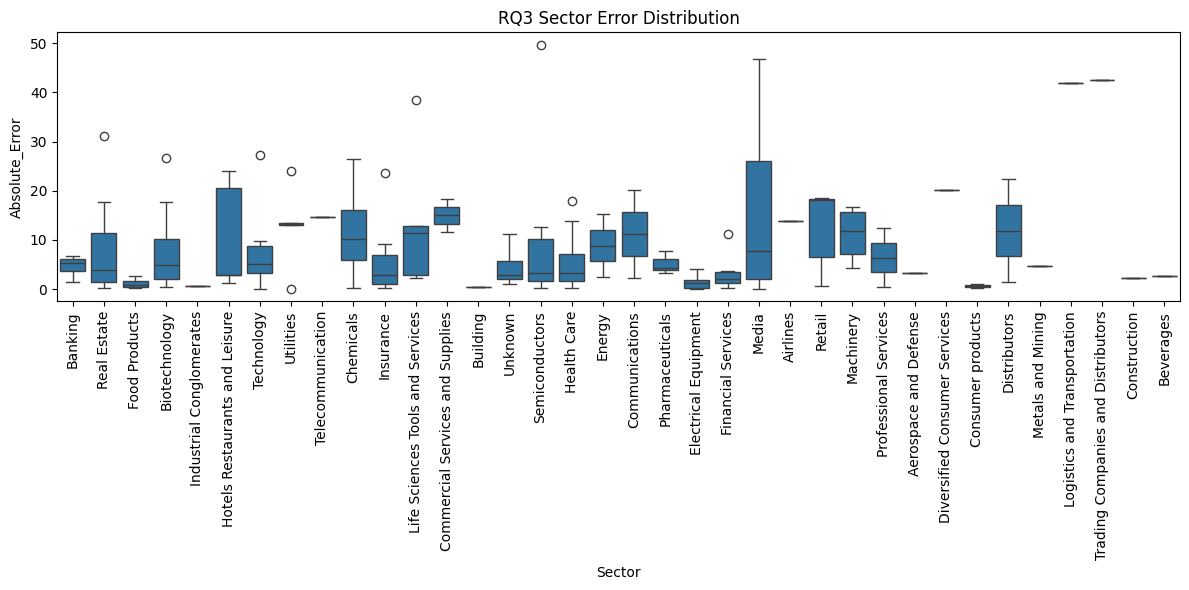

In [86]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=audit_df,
    x="Sector",
    y="Absolute_Error"
)

plt.xticks(
    rotation=90
)

plt.title(
    "RQ3 Sector Error Distribution"
)

plt.tight_layout()

plt.savefig(
    "outputs/figures/rq3_sector_error_boxplot.pdf",
    bbox_inches="tight"
)

plt.show()

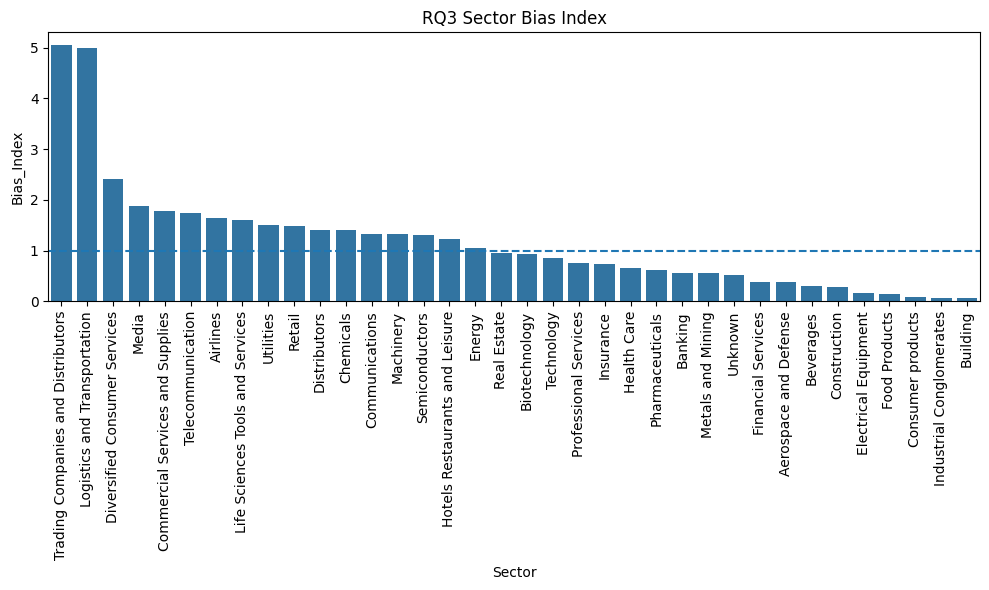

In [87]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=sector_bias_df,
    x="Sector",
    y="Bias_Index"
)

plt.axhline(
    1.0,
    linestyle="--"
)

plt.xticks(rotation=90)

plt.title(
    "RQ3 Sector Bias Index"
)

plt.tight_layout()

plt.savefig(
    "outputs/figures/rq3_sector_bias_barplot.pdf",
    bbox_inches="tight"
)

plt.show()

In [88]:
fairness_summary = sector_bias_df[
    [
        "Sector",
        "MAE",
        "Bias_Index"
    ]
].copy()

fairness_summary["Fairness_Status"] = np.where(
    fairness_summary["Bias_Index"] > 1,
    "Potential Bias",
    "Acceptable"
)

fairness_summary

,Sector,MAE,Bias_Index,Fairness_Status
33,Trading Companies and Distributors,42.496338,5.050923,Potential Bias
32,Logistics and Transportation,41.991211,4.990886,Potential Bias
28,Diversified Consumer Services,20.200745,2.400969,Potential Bias
22,Media,15.802560,1.878221,Potential Bias
12,Commercial Services and Supplies,14.967621,1.778984,Potential Bias
8,Telecommunication,14.635986,1.739567,Potential Bias
23,Airlines,13.809875,1.641379,Potential Bias
11,Life Sciences Tools and Services,13.560522,1.611742,Potential Bias
7,Utilities,12.713892,1.511116,Potential Bias
24,Retail,12.428723,1.477222,Potential Bias


In [91]:
fairness_summary.to_csv(
    "outputs/tables/rq3_sector_fairness_summary.csv",
    index=False
)

In [92]:
worst_sector = sector_bias_df.iloc[0]

print(
    "Most affected sector:"
)

print(
    worst_sector["Sector"]
)

print(
    "Bias Index:",
    round(
        worst_sector["Bias_Index"],
        3
    )
)

Most affected sector:
Trading Companies and Distributors
Bias Index: 5.051


In [93]:
print("="*60)
print("RQ3 COMPLETE")
print("="*60)

print()

print(
    "outputs/figures/rq3_sector_error_boxplot.pdf"
)

print(
    "outputs/figures/rq3_sector_bias_barplot.pdf"
)

print(
    "outputs/tables/rq3_sector_bias_results.csv"
)

print(
    "outputs/tables/rq3_sector_fairness_summary.csv"
)

sector_bias_df.head()

RQ3 COMPLETE

outputs/figures/rq3_sector_error_boxplot.pdf
outputs/figures/rq3_sector_bias_barplot.pdf
outputs/tables/rq3_sector_bias_results.csv
outputs/tables/rq3_sector_fairness_summary.csv


,Sector,Sample_Size,MAE,RMSE,Mean_Error,Bias_Index
33,Trading Companies and Distributors,1,42.496338,42.496338,42.496338,5.050923
32,Logistics and Transportation,1,41.991211,41.991211,41.991211,4.990886
28,Diversified Consumer Services,1,20.200745,20.200745,-20.200745,2.400969
22,Media,7,15.802560,23.671472,-8.658552,1.878221
12,Commercial Services and Supplies,2,14.967621,15.353077,3.418671,1.778984


In [94]:
!pip install xgboost -q

In [95]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import matplotlib.pyplot as plt
import seaborn as sns

In [96]:
os.makedirs("outputs", exist_ok=True)
os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)

In [97]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/alistairking/public-company-esg-ratings-dataset/data.csv
/kaggle/input/datasets/jaidityachopra/esg-sustainability-reports-of-s-and-p-500-companies/preprocessed_content.csv


In [105]:
reports = pd.read_csv(
    "/kaggle/input/datasets/jaidityachopra/esg-sustainability-reports-of-s-and-p-500-companies/preprocessed_content.csv"
)

print(reports.shape)
reports.head()

(866, 10)


,Unnamed: 0,filename,ticker,year,preprocessed_content,ner_entities,e_score,s_score,g_score,total_score
0,0,ASX_BSX_2020.pdf,BSX,2020,style guide colour colour use imagecolour prof...,"['bk%', 'rgb', 'un', 'el ectric mine consortiu...",3.16,18.00,11.83,32.98
1,1,ASX_BSX_2022.pdf,BSX,2022,sustainability report look mining green office...,"['murray street', 'west perth', 'west perth', ...",2.83,12.86,10.32,26.02
2,2,ASX_EXR_2022.pdf,EXR,2022,report environment social governance esg basel...,"['september', 'mongolia', 'australia', 'austra...",3.81,4.28,5.86,13.94
3,3,LSE_ADM_2019.pdf,ADM,2019,corporate social responsibilty report introduc...,"['david stevens', 'csr board', 'just over yea...",16.38,14.20,5.90,36.36
4,4,LSE_ADM_2020.pdf,ADM,2020,sustainability admiral commit maintain respons...,"['year', 'health & wellbeing', 'a -month', 'on...",15.89,13.51,5.38,34.78


In [106]:
print(reports.columns.tolist())

['Unnamed: 0', 'filename', 'ticker', 'year', 'preprocessed_content', 'ner_entities', 'e_score', 's_score', 'g_score', 'total_score']


In [107]:
df = reports[
    [
        "ticker",
        "preprocessed_content",
        "total_score"
    ]
].copy()

df.head()

,ticker,preprocessed_content,total_score
0,BSX,style guide colour colour use imagecolour prof...,32.98
1,BSX,sustainability report look mining green office...,26.02
2,EXR,report environment social governance esg basel...,13.94
3,ADM,corporate social responsibilty report introduc...,36.36
4,ADM,sustainability admiral commit maintain respons...,34.78


In [108]:
df = df.dropna(
    subset=[
        "preprocessed_content",
        "total_score"
    ]
)

df = df[
    df["preprocessed_content"].str.len() > 50
]

print(df.shape)

(866, 3)


In [119]:
tfidf = TfidfVectorizer(
    max_features=1000,
    stop_words="english"
)

In [112]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [120]:
models = {
    "Linear Regression":
        LinearRegression(),

    "Random Forest":
        RandomForestRegressor(
            n_estimators=50,
            random_state=42,
            n_jobs=-1
        ),

    "XGBoost":
        XGBRegressor(
            n_estimators=100,
            max_depth=4,
            learning_rate=0.1,
            random_state=42,
            tree_method="hist",
            n_jobs=-1
        )
}

In [121]:
results = []

predictions_dict = {}

for name, model in models.items():

    print("Training:", name)

    model.fit(
        X_train,
        y_train
    )

    preds = model.predict(
        X_test
    )

    predictions_dict[name] = preds

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            preds
        )
    )

    mae = mean_absolute_error(
        y_test,
        preds
    )

    r2 = r2_score(
        y_test,
        preds
    )

    results.append([
        name,
        rmse,
        mae,
        r2
    ])

Training: Linear Regression
Training: Random Forest
Training: XGBoost


In [122]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "RMSE",
        "MAE",
        "R2"
    ]
)

results_df

,Model,RMSE,MAE,R2
0,Linear Regression,3.337211,2.470751,0.795555
1,Random Forest,5.158538,4.060618,0.511503
2,XGBoost,4.875675,3.704925,0.563606


In [123]:
results_df.to_csv(
    "outputs/tables/rq4_model_comparison.csv",
    index=False
)

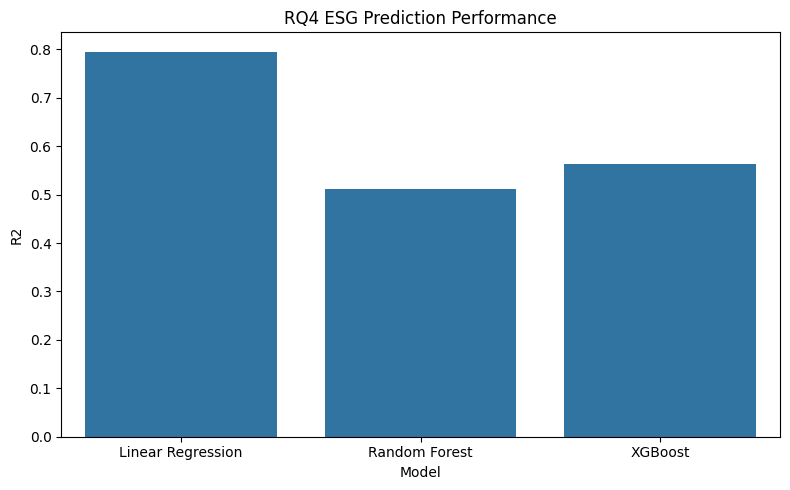

In [124]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="R2"
)

plt.title(
    "RQ4 ESG Prediction Performance"
)

plt.tight_layout()

plt.savefig(
    "outputs/figures/rq4_model_comparison.pdf",
    bbox_inches="tight"
)

plt.show()

In [125]:
best_model_name = (
    results_df
    .sort_values(
        "R2",
        ascending=False
    )
    .iloc[0]["Model"]
)

best_model_name

'Linear Regression'

In [126]:
best_preds = predictions_dict[
    best_model_name
]

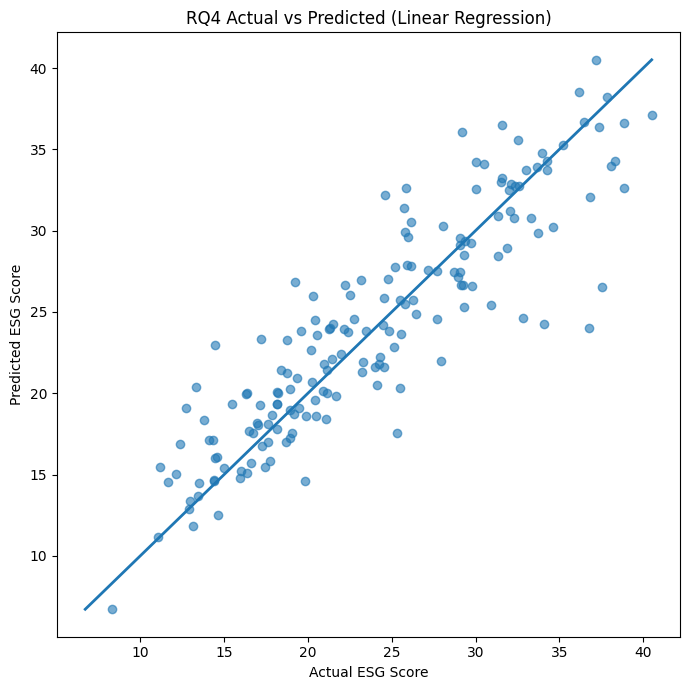

In [127]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    best_preds,
    alpha=0.6
)

min_val = min(
    y_test.min(),
    best_preds.min()
)

max_val = max(
    y_test.max(),
    best_preds.max()
)

plt.plot(
    [min_val,max_val],
    [min_val,max_val],
    linewidth=2
)

plt.xlabel(
    "Actual ESG Score"
)

plt.ylabel(
    "Predicted ESG Score"
)

plt.title(
    f"RQ4 Actual vs Predicted ({best_model_name})"
)

plt.tight_layout()

plt.savefig(
    "outputs/figures/rq4_actual_vs_predicted.pdf",
    bbox_inches="tight"
)

plt.show()

In [128]:
prediction_samples = pd.DataFrame({
    "Actual_ESG":
        y_test.values,

    "Predicted_ESG":
        best_preds
})

prediction_samples.head(25)

,Actual_ESG,Predicted_ESG
0,32.84,24.612563
1,37.52,26.518215
2,25.13,22.833534
3,33.29,30.788893
4,21.11,18.398120
5,33.03,33.743777
6,25.82,29.919476
7,17.60,17.028511
8,34.10,24.257309
9,24.62,32.202544


In [130]:
prediction_samples.to_csv(
    "outputs/tables/rq4_prediction_samples.csv",
    index=False
)

In [131]:
best_model_metrics = (
    results_df
    .sort_values(
        "R2",
        ascending=False
    )
    .iloc[0]
)

print(
    "Best Model:",
    best_model_metrics["Model"]
)

print(
    "R²:",
    round(
        best_model_metrics["R2"],
        3
    )
)

Best Model: Linear Regression
R²: 0.796


In [132]:
print("="*60)
print("RQ4 COMPLETE")
print("="*60)

print()

print(
    "outputs/figures/rq4_actual_vs_predicted.pdf"
)

print(
    "outputs/figures/rq4_model_comparison.pdf"
)

print(
    "outputs/tables/rq4_model_comparison.csv"
)

print(
    "outputs/tables/rq4_prediction_samples.csv"
)

results_df

RQ4 COMPLETE

outputs/figures/rq4_actual_vs_predicted.pdf
outputs/figures/rq4_model_comparison.pdf
outputs/tables/rq4_model_comparison.csv
outputs/tables/rq4_prediction_samples.csv


,Model,RMSE,MAE,R2
0,Linear Regression,3.337211,2.470751,0.795555
1,Random Forest,5.158538,4.060618,0.511503
2,XGBoost,4.875675,3.704925,0.563606


In [133]:
!pip install xgboost -q

In [134]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.ensemble import IsolationForest

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import matplotlib.pyplot as plt
import seaborn as sns

In [135]:
os.makedirs("outputs", exist_ok=True)
os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)

In [136]:
reports = pd.read_csv(
    "/kaggle/input/datasets/jaidityachopra/esg-sustainability-reports-of-s-and-p-500-companies/preprocessed_content.csv"
)

print(reports.shape)

(866, 10)


In [137]:
df = reports[
    [
        "ticker",
        "year",
        "preprocessed_content",
        "total_score"
    ]
].copy()

df.head()

,ticker,year,preprocessed_content,total_score
0,BSX,2020,style guide colour colour use imagecolour prof...,32.98
1,BSX,2022,sustainability report look mining green office...,26.02
2,EXR,2022,report environment social governance esg basel...,13.94
3,ADM,2019,corporate social responsibilty report introduc...,36.36
4,ADM,2020,sustainability admiral commit maintain respons...,34.78


In [138]:
df = df.dropna(
    subset=[
        "preprocessed_content",
        "total_score"
    ]
)

df = df[
    df["preprocessed_content"].str.len() > 50
]

print(df.shape)

(866, 4)


In [139]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X = tfidf.fit_transform(
    df["preprocessed_content"]
)

y = df["total_score"]

In [142]:
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X,
    y,
    df.index,
    test_size=0.20,
    random_state=42
)

In [147]:
model = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [148]:
preds = model.predict(
    X_test
)

In [149]:
audit_df = df.loc[idx_test].copy()

audit_df["actual_esg"] = y_test.values

audit_df["predicted_esg"] = preds

audit_df.head()

,ticker,year,preprocessed_content,total_score,actual_esg,predicted_esg
823,WEC,2019,sustainable progress endure enterprise corpora...,32.84,32.84,30.497581
483,EQT,2020,esg report executive summary empower esg repor...,37.52,37.52,29.314169
651,NEM,2019,sustainability report sustainability report in...,25.13,25.13,24.847820
811,VMC,2020,welcome chairman ceo mission commitment safety...,33.29,33.29,26.460865
23,AKAM,2021,sustainability impact report table content let...,21.11,21.11,20.000715


In [150]:
audit_df["discrepancy"] = (
    audit_df["predicted_esg"]
    -
    audit_df["actual_esg"]
)

In [151]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

audit_df["risk_score"] = scaler.fit_transform(
    audit_df[
        ["discrepancy"]
    ]
)

In [152]:
iso = IsolationForest(
    contamination=0.10,
    random_state=42
)

audit_df["anomaly"] = iso.fit_predict(
    audit_df[
        [
            "discrepancy",
            "risk_score"
        ]
    ]
)

In [153]:
audit_df["risk_level"] = np.where(
    audit_df["anomaly"] == -1,
    "High Risk",
    "Normal"
)

In [154]:
greenwashing_table = audit_df[
    [
        "ticker",
        "year",
        "actual_esg",
        "predicted_esg",
        "discrepancy",
        "risk_score",
        "risk_level"
    ]
].copy()

greenwashing_table.head()

,ticker,year,actual_esg,predicted_esg,discrepancy,risk_score,risk_level
823,WEC,2019,32.84,30.497581,-2.342419,0.481766,Normal
483,EQT,2020,37.52,29.314169,-8.205831,0.286098,Normal
651,NEM,2019,25.13,24.847820,-0.282180,0.550518,Normal
811,VMC,2020,33.29,26.460865,-6.829135,0.332040,Normal
23,AKAM,2021,21.11,20.000715,-1.109285,0.522916,Normal


In [155]:
greenwashing_table.to_csv(
    "outputs/tables/rq5_greenwashing_audit.csv",
    index=False
)

In [156]:
high_risk = greenwashing_table[
    greenwashing_table["risk_level"]
    ==
    "High Risk"
]

high_risk = high_risk.sort_values(
    by="risk_score",
    ascending=False
)

high_risk.head(20)

,ticker,year,actual_esg,predicted_esg,discrepancy,risk_score,risk_level
764,SYY,2022,12.13,25.317089,13.187089,1.000000,High Risk
581,KMX,2019,13.45,22.029905,8.579905,0.846254,High Risk
326,APD,2020,11.64,20.079859,8.439859,0.841580,High Risk
514,GPC,2023,13.14,21.440517,8.300517,0.836930,High Risk
290,ACN,2020,13.32,21.496901,8.176901,0.832805,High Risk
512,GPC,2021,12.75,20.446350,7.696350,0.816769,High Risk
110,FITB,2022,18.73,26.025513,7.295513,0.803393,High Risk
481,EQR,2022,11.05,17.969482,6.919482,0.790844,High Risk
29,AMZN,2019,33.69,26.055399,-7.634601,0.305160,High Risk
759,SYK,2021,33.72,25.234690,-8.485310,0.276771,High Risk


In [157]:
high_risk.to_csv(
    "outputs/tables/rq5_high_risk_companies.csv",
    index=False
)

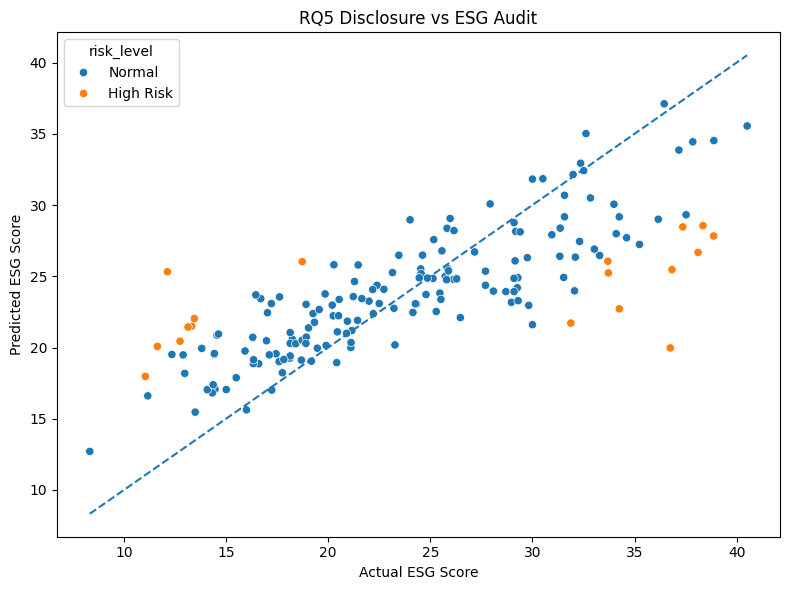

In [158]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=audit_df,
    x="actual_esg",
    y="predicted_esg",
    hue="risk_level"
)

plt.plot(
    [
        audit_df["actual_esg"].min(),
        audit_df["actual_esg"].max()
    ],
    [
        audit_df["actual_esg"].min(),
        audit_df["actual_esg"].max()
    ],
    linestyle="--"
)

plt.xlabel("Actual ESG Score")
plt.ylabel("Predicted ESG Score")

plt.title(
    "RQ5 Disclosure vs ESG Audit"
)

plt.tight_layout()

plt.savefig(
    "outputs/figures/rq5_greenwashing_scatter.pdf",
    bbox_inches="tight"
)

plt.show()

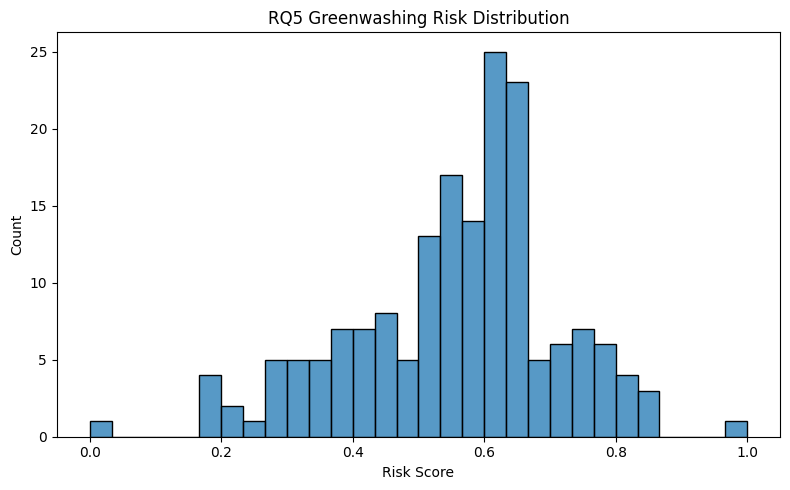

In [159]:
plt.figure(figsize=(8,5))

sns.histplot(
    audit_df["risk_score"],
    bins=30
)

plt.title(
    "RQ5 Greenwashing Risk Distribution"
)

plt.xlabel(
    "Risk Score"
)

plt.tight_layout()

plt.savefig(
    "outputs/figures/rq5_risk_distribution.pdf",
    bbox_inches="tight"
)

plt.show()

In [160]:
summary_stats = pd.DataFrame({
    "Metric":[
        "Total Companies",
        "High Risk Companies",
        "Mean Risk Score",
        "Max Risk Score"
    ],
    "Value":[
        len(audit_df),
        len(high_risk),
        audit_df["risk_score"].mean(),
        audit_df["risk_score"].max()
    ]
})

summary_stats

,Metric,Value
0,Total Companies,174.000000
1,High Risk Companies,18.000000
2,Mean Risk Score,0.557224
3,Max Risk Score,1.000000


In [161]:
summary_stats.to_csv(
    "outputs/tables/rq5_governance_summary.csv",
    index=False
)

In [162]:
high_risk[
    [
        "ticker",
        "actual_esg",
        "predicted_esg",
        "risk_score"
    ]
].head(15)

,ticker,actual_esg,predicted_esg,risk_score
764,SYY,12.13,25.317089,1.000000
581,KMX,13.45,22.029905,0.846254
326,APD,11.64,20.079859,0.841580
514,GPC,13.14,21.440517,0.836930
290,ACN,13.32,21.496901,0.832805
512,GPC,12.75,20.446350,0.816769
110,FITB,18.73,26.025513,0.803393
481,EQR,11.05,17.969482,0.790844
29,AMZN,33.69,26.055399,0.305160
759,SYK,33.72,25.234690,0.276771


In [163]:
print("="*60)
print("RQ5 COMPLETE")
print("="*60)

print()

print(
    "outputs/figures/rq5_greenwashing_scatter.pdf"
)

print(
    "outputs/figures/rq5_risk_distribution.pdf"
)

print(
    "outputs/tables/rq5_greenwashing_audit.csv"
)

print(
    "outputs/tables/rq5_high_risk_companies.csv"
)

print(
    "outputs/tables/rq5_governance_summary.csv"
)

RQ5 COMPLETE

outputs/figures/rq5_greenwashing_scatter.pdf
outputs/figures/rq5_risk_distribution.pdf
outputs/tables/rq5_greenwashing_audit.csv
outputs/tables/rq5_high_risk_companies.csv
outputs/tables/rq5_governance_summary.csv
